In [264]:
import torch
import torchvision

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import polars as pl

from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

from torchmetrics.classification import BinaryAccuracy

from helper_function import plot_decision_boundary

In [265]:
breastDataset = fetch_openml("breast-w", as_frame = True).frame

In [266]:
X, y = fetch_openml("breast-w", return_X_y = True)

In [267]:
X = X.fillna(X.mean(), axis = 0)

<Axes: >

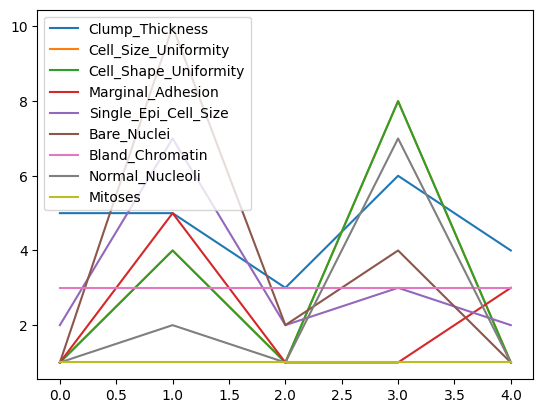

In [268]:
breastDataset.head().plot()

In [269]:
# pca = PCA(n_components = 2)
# X = pca.fit_transform(X)

X = X.values

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

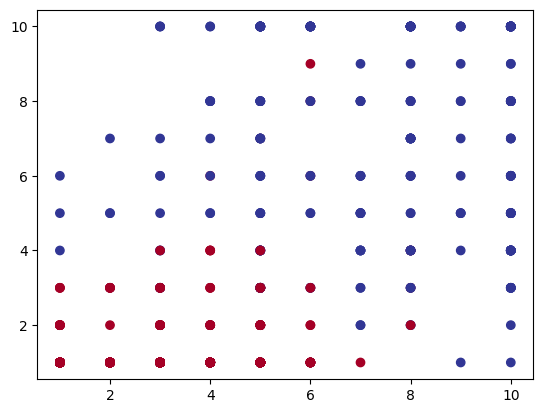

In [270]:
plt.scatter(X[:, 0], X[:, 1], c = y, cmap = plt.cm.RdYlBu)

In [271]:
X_tensor, y_tensor = torch.tensor(X, dtype = torch.float32), torch.tensor(y, dtype = torch.float32)

In [272]:
X_tensor[:5]

tensor([[ 5.,  1.,  1.,  1.,  2.,  1.,  3.,  1.,  1.],
        [ 5.,  4.,  4.,  5.,  7., 10.,  3.,  2.,  1.],
        [ 3.,  1.,  1.,  1.,  2.,  2.,  3.,  1.,  1.],
        [ 6.,  8.,  8.,  1.,  3.,  4.,  3.,  7.,  1.],
        [ 4.,  1.,  1.,  3.,  2.,  1.,  3.,  1.,  1.]])

In [273]:
y_tensor[:5]

tensor([0., 0., 0., 0., 0.])

In [274]:
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size = 0.2, shuffle = True, random_state = 42)

In [275]:
len(X_train), len(y_train), len(X_test), len(y_test)

(559, 559, 140, 140)

In [282]:
y_train.unique(), X_train.shape

(tensor([0., 1.]), torch.Size([559, 9]))

In [277]:
device = "mps" if torch.mps.is_available() else "cpu"

In [283]:
class BreastCancerModel(torch.nn.Module):
    def __init__(self, in_features = 9, out_features = 1, hidden_units = 32):
        super(BreastCancerModel, self).__init__()

        self.in_features = in_features
        self.out_features = out_features
        self.hidden_units = hidden_units

        self.layer = torch.nn.Sequential(
            torch.nn.Linear(in_features = self.in_features,
                           out_features = self.hidden_units),
            torch.nn.ReLU(inplace = True),
            torch.nn.Linear(in_features = self.hidden_units,
                           out_features = self.hidden_units),
            torch.nn.ReLU(inplace = True),
            torch.nn.Linear(in_features = self.hidden_units,
                           out_features = self.out_features)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer(x)

In [284]:
model = BreastCancerModel().to(device)

In [285]:
model

BreastCancerModel(
  (layer): Sequential(
    (0): Linear(in_features=9, out_features=32, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [286]:
with torch.inference_mode():
    y_logits = model(X_test.to(device)).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

y_pred[:5], y_test[:5]

(tensor([1., 1., 1., 1., 1.], device='mps:0'), tensor([0., 0., 0., 1., 0.]))

In [287]:
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 1e-3, weight_decay = 1e-4)
accuracy = BinaryAccuracy().to(device)

In [288]:
epochs = 1000

total_epochs, losses, test_losses = [], [], []

for epoch in range(epochs):
    model.train()
    y_logits = model(X_train.to(device)).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    train_acc = accuracy(y_pred, y_train.to(device))

    loss = criterion(y_logits, y_train.to(device))
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    model.eval()
    with torch.inference_mode():
        y_test_logits = model(X_test.to(device)).squeeze()
        y_test_pred = torch.round(torch.sigmoid(y_test_logits))

        test_acc = accuracy(y_test_pred, y_test.to(device))

        test_loss = criterion(y_test_logits, y_test.to(device))
        test_losses.append(test_loss.item())

    total_epochs.append(epoch)
    if epoch % (0.2 * epochs) == 0:
        print(f"Train Losses: {loss:.5f}, Train Accuracy: {train_acc:.2f}")
        print(f"Test Losses: {test_loss:.5f}, Test Accuracy: {test_acc:.2f} \n")


Train Losses: 0.72328, Train Accuracy: 0.35
Test Losses: 0.73145, Test Accuracy: 0.32 

Train Losses: 0.07926, Train Accuracy: 0.98
Test Losses: 0.10056, Test Accuracy: 0.96 

Train Losses: 0.04135, Train Accuracy: 0.98
Test Losses: 0.08974, Test Accuracy: 0.96 

Train Losses: 0.02470, Train Accuracy: 0.99
Test Losses: 0.11136, Test Accuracy: 0.95 

Train Losses: 0.01206, Train Accuracy: 1.00
Test Losses: 0.17857, Test Accuracy: 0.94 



RuntimeError: mat1 and mat2 shapes cannot be multiplied (10201x2 and 9x32)

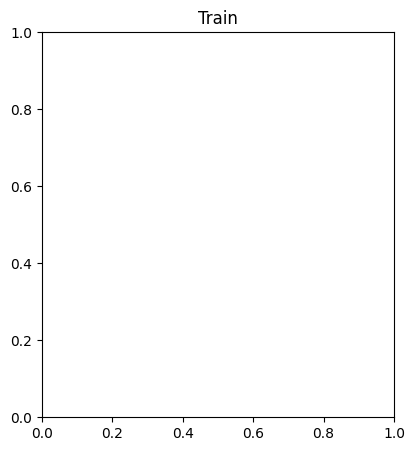

In [292]:
pca = PCA(n_components = 2)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

X_train, X_test = torch.tensor(X_train, dtype = torch.float32), torch.tensor(X_test, dtype = torch.float32)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

In [289]:
with torch.inference_mode():
    y_logits = model(X_test.to(device)).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

y_pred[:5], y_test[:5]

(tensor([0., 0., 0., 1., 0.], device='mps:0'), tensor([0., 0., 0., 1., 0.]))

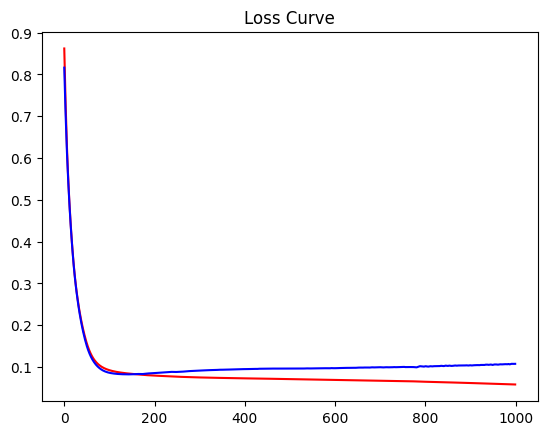

In [263]:
plt.plot(total_epochs, losses, label = "Training Loss", c="red")
plt.plot(total_epochs, test_losses, label = "Testing Loss", c="blue")
plt.title("Loss Curve")
plt.show()